In [1]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

fastf1.Cache.enable_cache('f1_cache')

session = fastf1.get_session(2025, 'Australia', 'R')
session.load(telemetry=True, weather=True, messages=False)

laps = session.laps
laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()
clean_laps = laps[laps['IsAccurate'] == True].copy()

finishing_order = session.results.sort_values('Position')['Abbreviation'].tolist()
top5 = session.results.sort_values('Position').head(5)['Abbreviation'].values

print("Loaded. Top 5:", top5)

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
Request for URL https://api.jolpi.ca/ergast/f1/2025/1/results.json failed; using cached response
Traceback (most recent call last):
  File "c:\Users\Kshitij\AppData\Local\Programs\Python\Python312\Lib\site-packages\urllib3\connection.py", line 204, in _new_conn
    sock = connection.create_connection(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Kshitij\AppData\Local\Programs\Python\Python312\Lib\site-packages\urllib3\util\connection.py", line 85, in create_connection
    raise err
  File "c:\Users\Kshitij\AppData\Local\Programs\Python\Python312\Lib\site-packages\urllib3\util\connection.py", line 73, in create_connection
    sock.connect(sa)
TimeoutError: timed out

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\Users\Ksh

Loaded. Top 5: ['NOR' 'VER' 'RUS' 'ANT' 'ALB']


In [2]:
nor_fast = session.laps.pick_drivers('NOR').pick_fastest()
ver_fast = session.laps.pick_drivers('VER').pick_fastest()

nor_tel = nor_fast.get_telemetry().add_distance()
ver_tel = ver_fast.get_telemetry().add_distance()

print(nor_tel.columns.tolist())
print(nor_tel.shape)

['Date', 'SessionTime', 'DriverAhead', 'DistanceToDriverAhead', 'Time', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source', 'RelativeDistance', 'Status', 'X', 'Y', 'Z', 'Distance']
(631, 18)


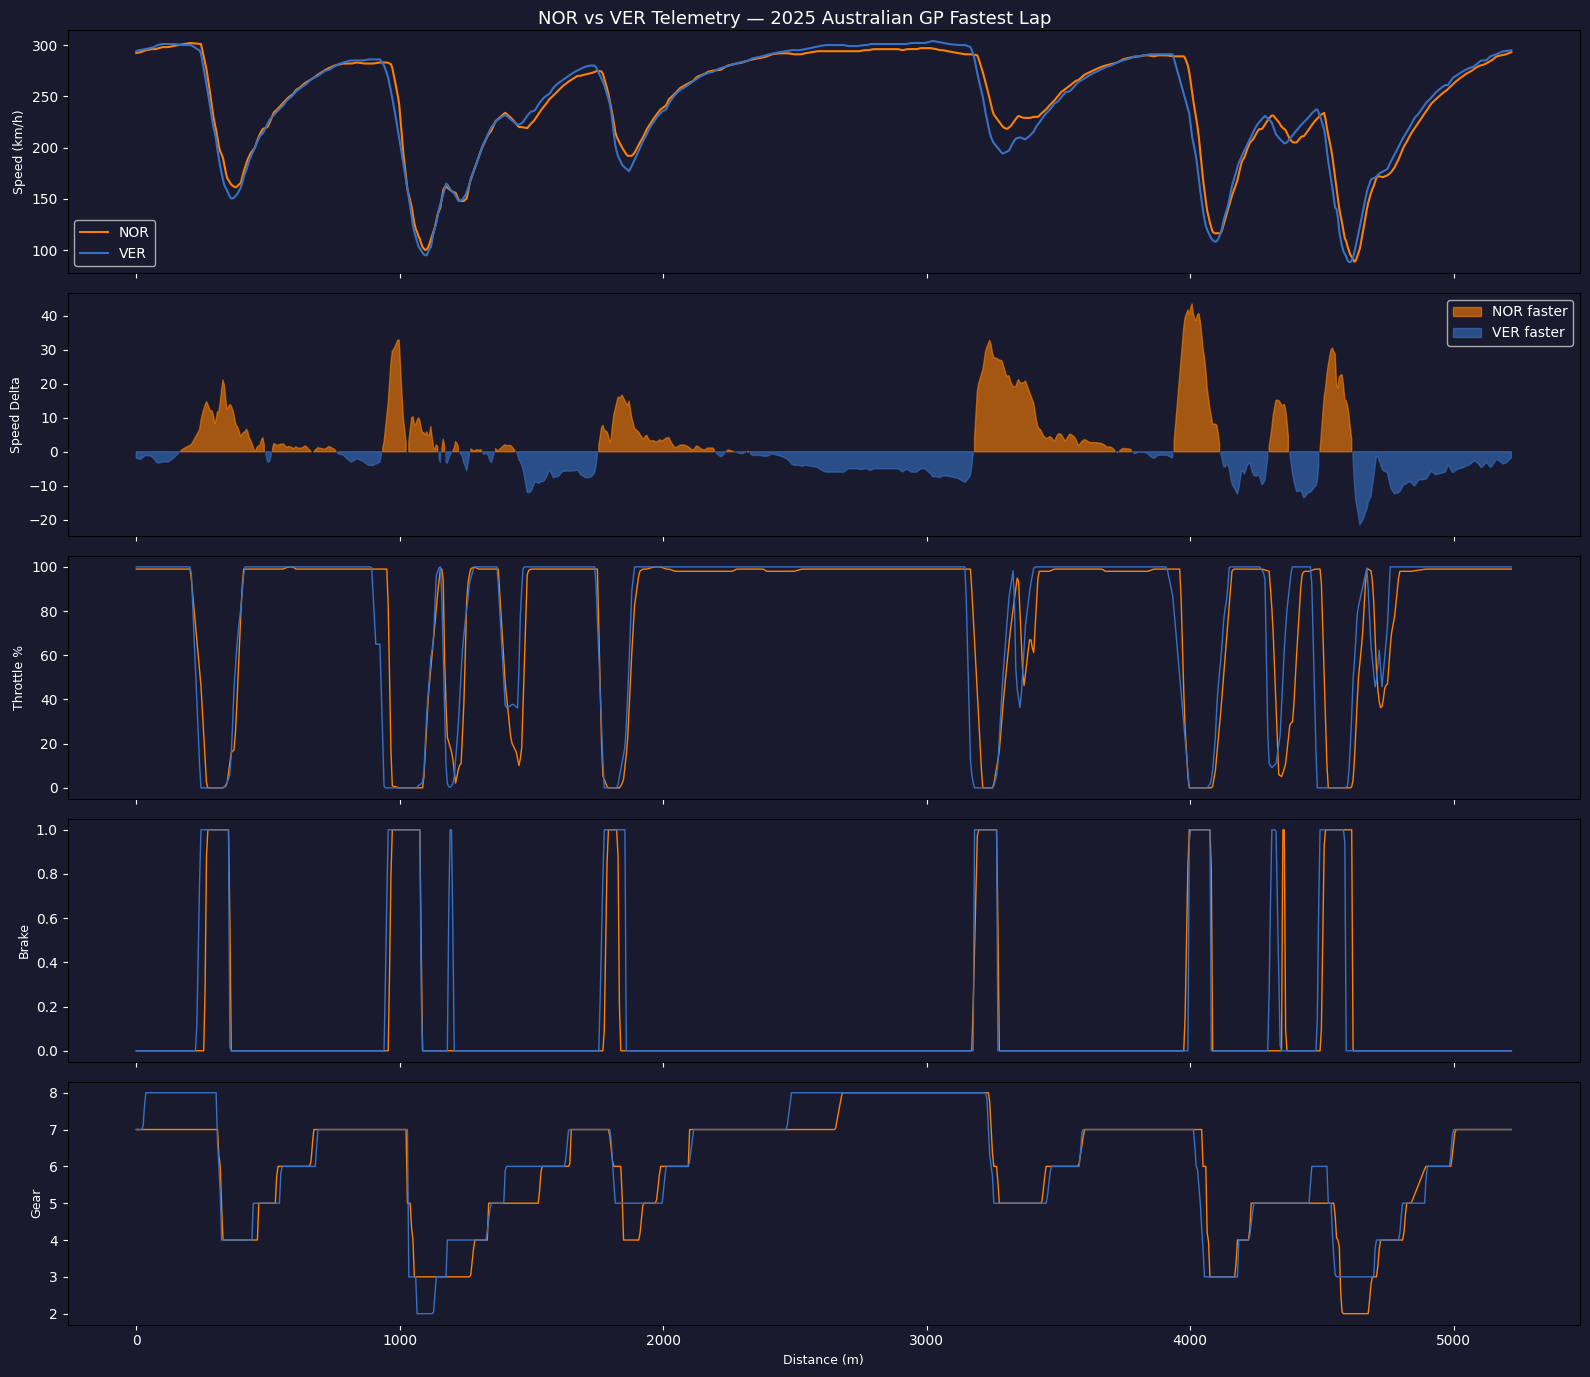

In [3]:
from scipy import interpolate

# Common distance axis
min_dist = max(nor_tel['Distance'].min(), ver_tel['Distance'].min())
max_dist = min(nor_tel['Distance'].max(), ver_tel['Distance'].max())
common_dist = np.linspace(min_dist, max_dist, 1000)

# Interpolate both drivers onto common axis
def interp(tel, channel):
    f = interpolate.interp1d(tel['Distance'], tel[channel], bounds_error=False, fill_value='extrapolate')
    return f(common_dist)

nor_speed = interp(nor_tel, 'Speed')
ver_speed = interp(ver_tel, 'Speed')
nor_throttle = interp(nor_tel, 'Throttle')
ver_throttle = interp(ver_tel, 'Throttle')
nor_brake = interp(nor_tel, 'Brake')
ver_brake = interp(ver_tel, 'Brake')
nor_gear = interp(nor_tel, 'nGear')
ver_gear = interp(ver_tel, 'nGear')

# Plot
fig, axes = plt.subplots(5, 1, figsize=(16, 14), facecolor='#1a1a2e', sharex=True)
for ax in axes:
    ax.set_facecolor('#1a1a2e')

# Speed
axes[0].plot(common_dist, nor_speed, color='#FF8000', label='NOR', linewidth=1.5)
axes[0].plot(common_dist, ver_speed, color='#3671C6', label='VER', linewidth=1.5)
axes[0].set_ylabel('Speed (km/h)', color='white', fontsize=9)
axes[0].legend(facecolor='#1a1a2e', labelcolor='white')

# Speed delta
delta = nor_speed - ver_speed
axes[1].fill_between(common_dist, delta, 0,
                     where=delta > 0, color='#FF8000', alpha=0.6, label='NOR faster')
axes[1].fill_between(common_dist, delta, 0,
                     where=delta < 0, color='#3671C6', alpha=0.6, label='VER faster')
axes[1].set_ylabel('Speed Delta', color='white', fontsize=9)
axes[1].legend(facecolor='#1a1a2e', labelcolor='white')

# Throttle
axes[2].plot(common_dist, nor_throttle, color='#FF8000', linewidth=1)
axes[2].plot(common_dist, ver_throttle, color='#3671C6', linewidth=1)
axes[2].set_ylabel('Throttle %', color='white', fontsize=9)

# Brake
axes[3].plot(common_dist, nor_brake, color='#FF8000', linewidth=1)
axes[3].plot(common_dist, ver_brake, color='#3671C6', linewidth=1)
axes[3].set_ylabel('Brake', color='white', fontsize=9)

# Gear
axes[4].plot(common_dist, nor_gear, color='#FF8000', linewidth=1)
axes[4].plot(common_dist, ver_gear, color='#3671C6', linewidth=1)
axes[4].set_ylabel('Gear', color='white', fontsize=9)
axes[4].set_xlabel('Distance (m)', color='white', fontsize=9)

for ax in axes:
    ax.tick_params(colors='white')

fig.suptitle('NOR vs VER Telemetry — 2025 Australian GP Fastest Lap', color='white', fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
sector_cols = ['Driver', 'Sector1Time', 'Sector2Time', 'Sector3Time']
sector_laps = clean_laps[sector_cols].copy()

# Convert to seconds
for col in ['Sector1Time', 'Sector2Time', 'Sector3Time']:
    sector_laps[col] = sector_laps[col].dt.total_seconds()

# Theoretical best per driver
theo_best = sector_laps.groupby('Driver').min()
theo_best['TheoBest'] = theo_best['Sector1Time'] + theo_best['Sector2Time'] + theo_best['Sector3Time']
theo_best = theo_best.sort_values('TheoBest')

print(theo_best.head(10))

        Sector1Time  Sector2Time  Sector3Time  TheoBest
Driver                                                 
NOR          28.553       18.537       34.890    81.980
VER          28.766       18.154       35.634    82.554
LAW          28.698       18.234       35.810    82.742
PIA          28.966       18.119       35.663    82.748
BOR          29.066       18.781       35.918    83.765
LEC          29.433       17.831       36.912    84.176
HAM          29.552       18.440       36.191    84.183
TSU          29.553       18.100       36.541    84.194
ALB          29.496       18.200       36.901    84.597
GAS          29.467       18.594       36.606    84.667


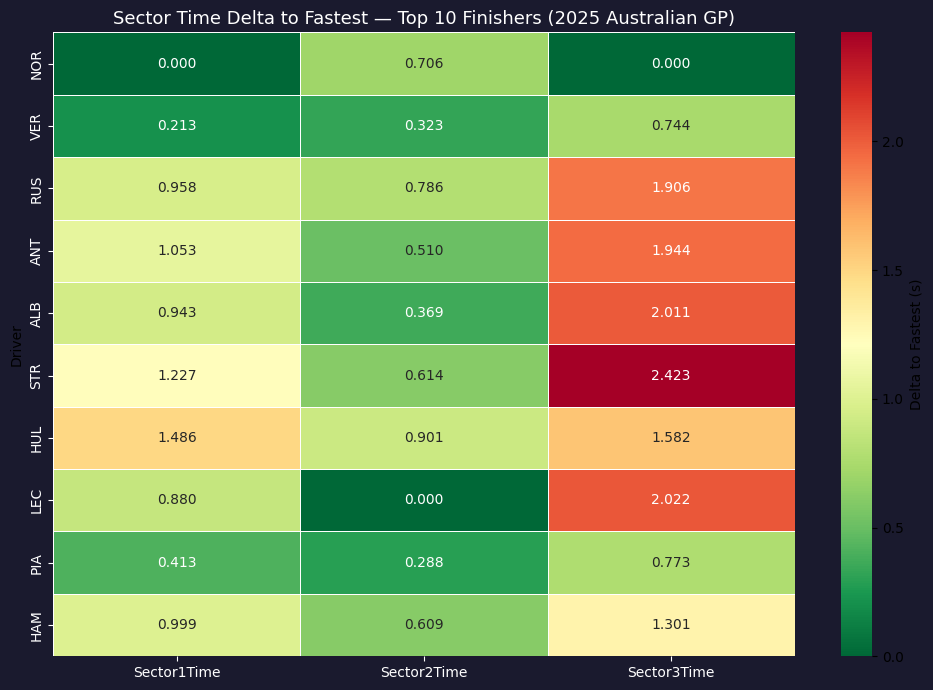

In [6]:
heat_data = theo_best.loc[top10, ['Sector1Time', 'Sector2Time', 'Sector3Time']].copy()
heat_norm = heat_data - heat_data.min()

fig, ax = plt.subplots(figsize=(10, 7), facecolor='#1a1a2e')
ax.set_facecolor('#1a1a2e')

sns.heatmap(heat_norm, ax=ax, cmap='RdYlGn_r', annot=True, fmt='.3f',
            linewidths=0.5, cbar_kws={'label': 'Delta to Fastest (s)'})

ax.set_title('Sector Time Delta to Fastest — Top 10 Finishers (2025 Australian GP)',
             color='white', fontsize=13)
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

In [7]:
weather = session.weather_data.copy()
weather['Time'] = weather['Time'].dt.total_seconds()

print(weather.columns.tolist())
print(weather.shape)

['Time', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed']
(178, 8)


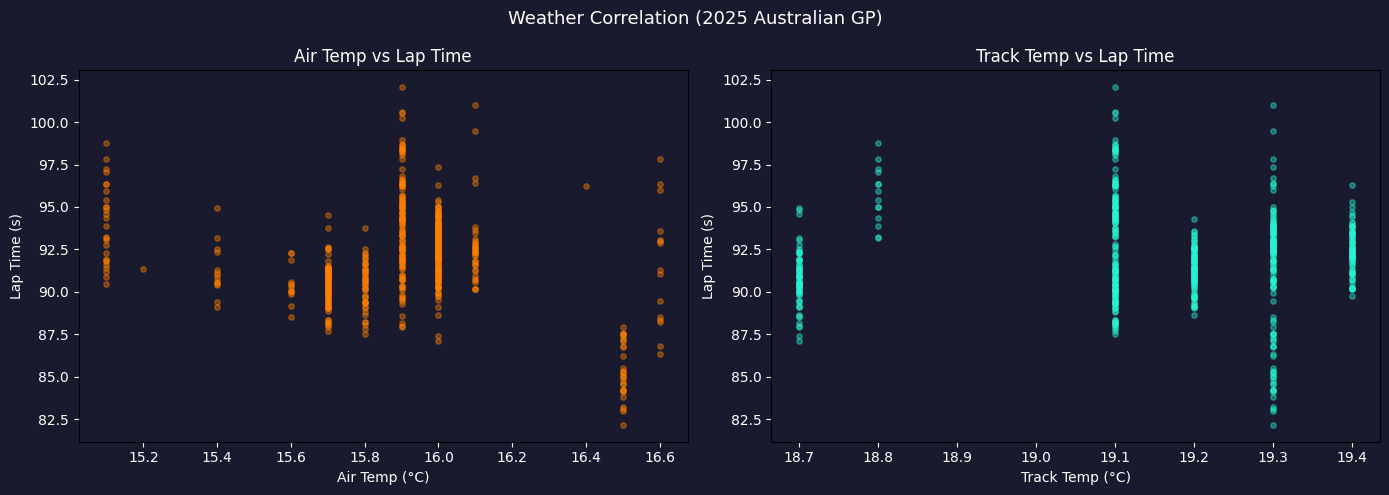

In [8]:
# Prep laps for merge
merge_laps = clean_laps[['LapStartTime', 'LapTimeSeconds', 'Driver']].copy()
merge_laps['LapStartSeconds'] = merge_laps['LapStartTime'].dt.total_seconds()

# Merge weather onto laps by nearest time
weather_merge = pd.merge_asof(
    merge_laps.sort_values('LapStartSeconds'),
    weather.sort_values('Time'),
    left_on='LapStartSeconds',
    right_on='Time'
)

# Plot — 2 panels: air temp vs lap time, track temp vs lap time
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#1a1a2e')
for ax in axes:
    ax.set_facecolor('#1a1a2e')

axes[0].scatter(weather_merge['AirTemp'], weather_merge['LapTimeSeconds'],
                alpha=0.4, color='#FF8000', s=15)
axes[0].set_xlabel('Air Temp (°C)', color='white')
axes[0].set_ylabel('Lap Time (s)', color='white')
axes[0].set_title('Air Temp vs Lap Time', color='white')

axes[1].scatter(weather_merge['TrackTemp'], weather_merge['LapTimeSeconds'],
                alpha=0.4, color='#27F4D2', s=15)
axes[1].set_xlabel('Track Temp (°C)', color='white')
axes[1].set_ylabel('Lap Time (s)', color='white')
axes[1].set_title('Track Temp vs Lap Time', color='white')

for ax in axes:
    ax.tick_params(colors='white')

fig.suptitle('Weather Correlation (2025 Australian GP)', color='white', fontsize=13)
plt.tight_layout()
plt.show()